# DTEx231G. LodeSTAR to Detect Plankton

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx231G_LodeSTAR_track_plankton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack deeplay  # Uncomment if running in colab/kaggle

???

In [2]:
import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import torch

## 1. Loading the Images of Plankton

???

In [6]:
def normalize_min_max(images):
    """Normalizes image by intensity."""

    max_intensity = np.max(images)
    min_intensity = np.min(images)

    normalized_images = (images - min_intensity) / (
        max_intensity - min_intensity
    )

    return normalized_images

???

In [32]:
images = np.load("./assets/plankton.npy")

images = images[:, :, :, 0]  # Select only first color channel

images = normalize_min_max(images)

???

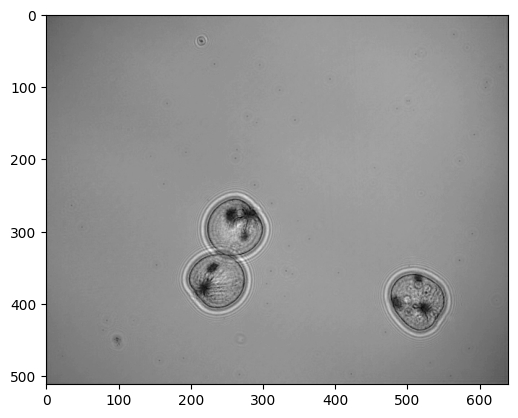

In [34]:
plt.imshow(images[0], cmap="gray")
plt.show()

## 2. Cropping a Plankton

???

In [36]:
t, x, y, w = (0, 450, 320, 150)
crop = images[t, y : y + w, x : x + w]

???

In [37]:
print(f"Crop shape = {crop.shape}")

Crop shape = (150, 150)


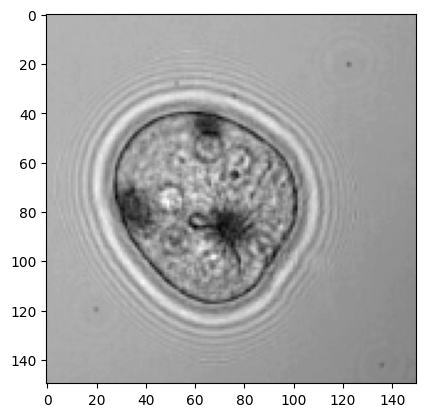

In [38]:
plt.imshow(crop, cmap="gray")
plt.show()

## 3. Training LodeSTAR

Define training pipeline, dataset, and dataloader ...

In [ ]:
training_crop = crop[np.newaxis]  # Add empty batch dimension

downsample = 5

training_pipeline = (
    dt.Value(training_crop)
    >> dt.AveragePooling(ksize=(1, downsample, downsample))
    >> dt.Affine(
        rotate=lambda: np.random.rand() * np.pi * 2,
        scale=lambda: np.random.uniform(0.95, 1.05, 2),
    )
    >> dt.Add(lambda: np.random.randn() * 0.2)
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0, 0.01))
    >> dt.Multiply(lambda: np.random.uniform(0.3, 1.6))
    >> dt.pytorch.ToTensor(dtype=torch.float32)
)

train_dataset = dt.pytorch.Dataset(
    training_pipeline,
    length=256,
    replace=False,
)

dataloader = dl.DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
)

... define LodeSTAR model ...

In [40]:
model = dl.LodeSTAR(n_transforms=4, optimizer=dl.Adam(lr=1e-4)).build()

... train it ...

In [41]:
trainer_lodestar = dl.Trainer(max_epochs=100, accelerator="auto")
trainer_lodestar.fit(model, dataloader)

/Users/giovannivolpe/Documents/GitHub/DeepLearningCrashCourse/py_env_book/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name          | Type                       | Params | Mode 
---------------------------------------------------------------------
0 | model         | ConvolutionalNeuralNetwork | 251 K  | train
1 | between_loss  | L1Loss                     | 0      | train
2 | within_loss   | L1Loss                     | 0      | train
3 | train_metrics | MetricCollection           | 0      | train
4 | val_metrics   | MetricCollection           | 0      | train
5 | test_metrics  | MetricCollection           | 0      | train
6 | optimizer     | Adam                       | 0      | train
---------------------------------------------------------------------
251 K     Trainable params
0         Non-trainable params
251 K     Total params
1.004     Total estimated

Training: |          | 0/? [00:00<?, ?it/s]

... plot training history.

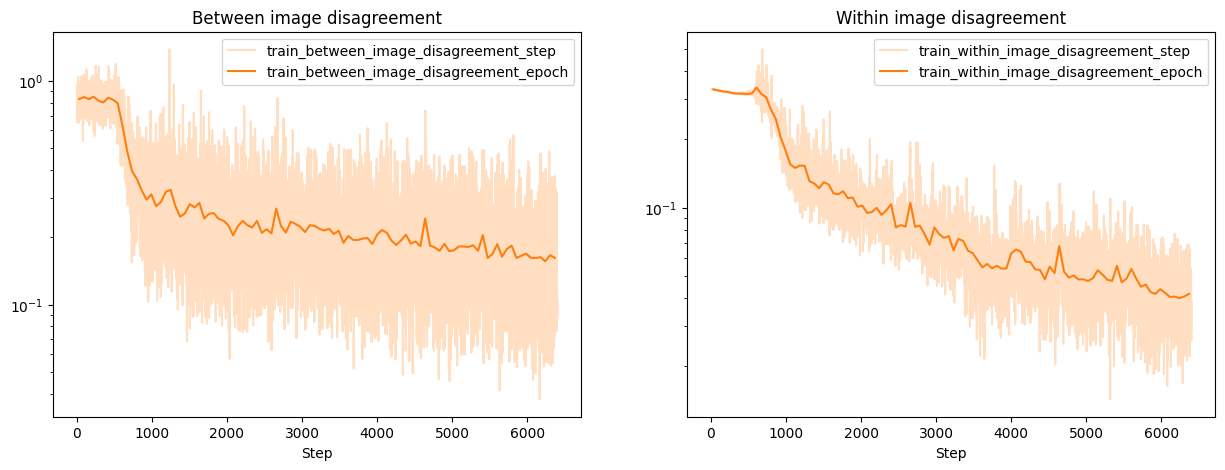

In [42]:
trainer_lodestar.history.plot();

## 4. Testing the Model

Extract the a frame from the movie ..

In [60]:
frame_index = 9

experimental_image = images[
    frame_index : frame_index + 1,
    ::downsample,
    ::downsample,
]

... convert the image into a PyTorch tensor ...

In [61]:
image_tensor = (
    torch.as_tensor(experimental_image, dtype=torch.float32)
    .detach()
    .to(model.device)
    .unsqueeze(0)
)

... execute LodeSTAR (may need to tune the parameters to get optimal performance) ...

In [62]:
alpha = 0.95
cutoff = 0.8

detections = model.detect(
    image_tensor, alpha=alpha, beta=1 - alpha, cutoff=cutoff, mode="quantile"
)[0]

... and plot the result.

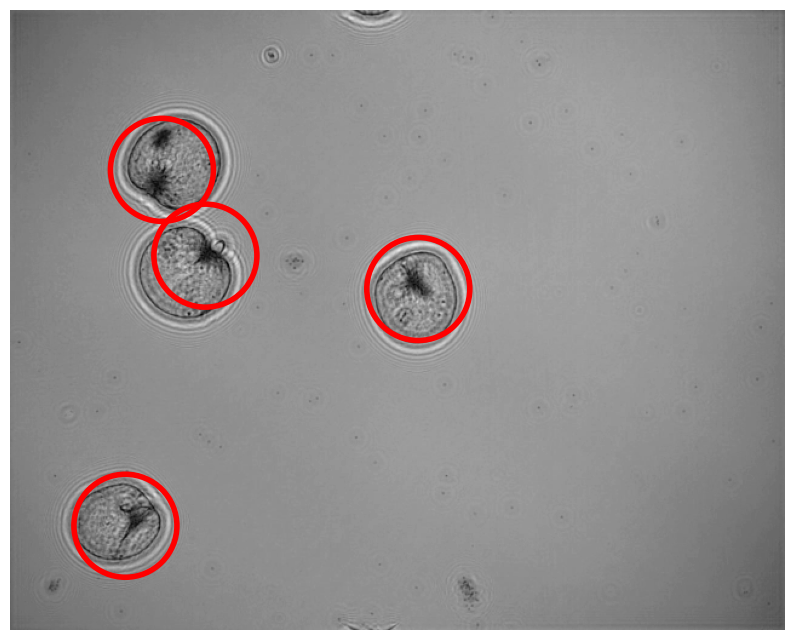

In [63]:
plt.figure(figsize=(10, 10))
plt.imshow(images[frame_index], cmap="gray")
plt.axis("off")
plt.scatter(
    detections[:, 1] * downsample,
    detections[:, 0] * downsample,
    s=5500,
    linewidths=4,
    facecolors="none",
    edgecolors="r",
)